# **Data visual with hypothesis**

## Hypothesis

* Sales are seasonal
* The UK carries most of revenue
* Repeat customers spend more money

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [97]:
import os
current_dir = os.getcwd()
current_dir

'c:\\'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [98]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [99]:
current_dir = os.getcwd()
current_dir

'c:\\'

In [100]:
import pandas as pd
import numpy as np

In [101]:
df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_11600\1985259099.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
530099,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
530100,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
530101,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
530102,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [112]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
530099    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
530100    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
530101    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
530102    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
530103    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  Cus

# Hypothesis 1 (Bar Chart)

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [103]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df["Month"] = df["InvoiceDate"].dt.month

In [104]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

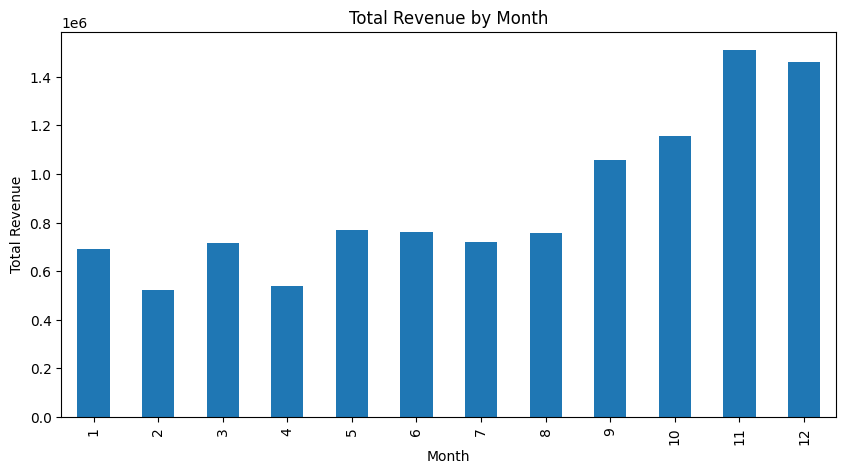

In [105]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")

plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.show()

---

---

# Hypothesis 2 (Bar Chart)

In [106]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [107]:
country_revenue = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: TotalAmount, dtype: float64

In [108]:
revenue_df = country_revenue.reset_index()
revenue_df.columns = ["Country", "Revenue"]

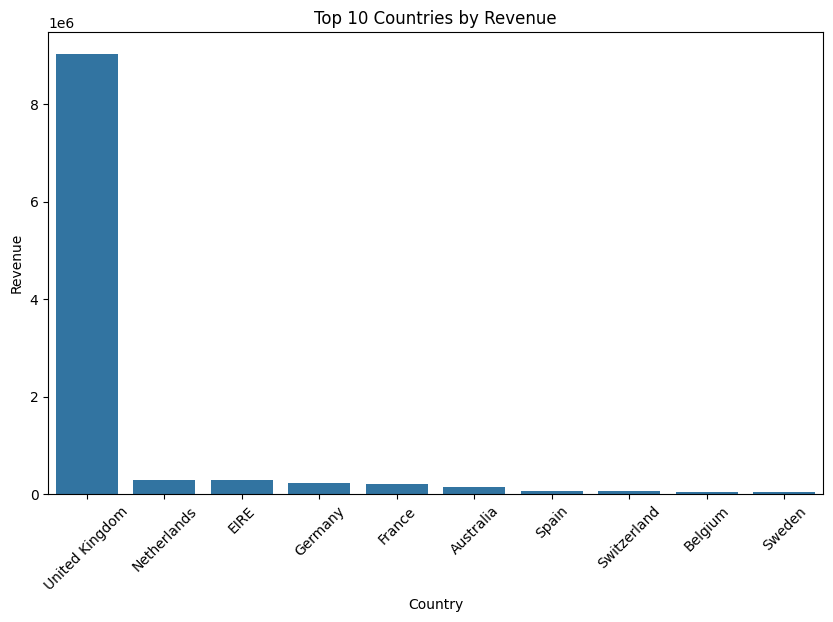

In [109]:
top10 = revenue_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Country",
    y="Revenue"
)

plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)

plt.show()

# Hypothesis 3 (Boxplot)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11600\1674716734.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")


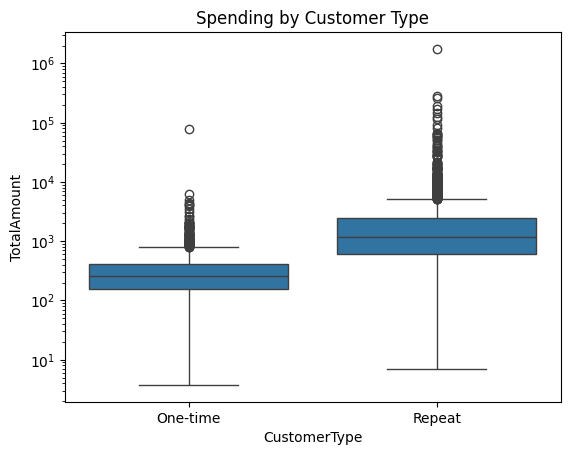

In [110]:
df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")

customer = df.groupby("CustomerID").agg({
    "TotalAmount": "sum",
    "InvoiceNo": "nunique"
}).reset_index()

customer["CustomerType"] = customer["InvoiceNo"].apply(lambda x: "Repeat" if x > 1 else "One-time")

sns.boxplot(data=customer, x="CustomerType", y="TotalAmount")

plt.yscale("log")
plt.title("Spending by Customer Type")
plt.show()

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [111]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)